# Lab 5 - Text Summarisation of Student Feedback

Topic: extractive and abstractive summarisation of a university student-feedback report, compared with a human
reference summary using ROUGE-1, ROUGE-2 and ROUGE-L. The code is the Lab 5 solution in `lab 5/solution/`, called
from this notebook after a `sys.path` insert. No `.py`, data or output file of the repo is modified.

**Sections**
- Setup and flags
- (a) Pre-processing: removal of unnecessary text, sentence segmentation, tokenisation
- (b) Graph / statistical extractive summarisers: Frequency, TF-IDF, TextRank, LexRank, Feature-based
- (c1) Deep learning trained from scratch: RNN and LSTM extractors, self-attention extractor, RNN and LSTM
  encoder-decoder, Seq2Seq + attention, Transformer
- (c2) Pre-trained: BERT and SBERT (extractive), BART, PEGASUS, T5 (abstractive)
- (d) ROUGE-1 / ROUGE-2 / ROUGE-L (precision, recall, F1) implemented from scratch: results table and chart
- Final comparison, CAUTION note, notes

**Flags (set in the setup cell)**
- `RUN_PRETRAINED = True`: runs section (c2). Needs internet on first use (about 5 GB of models, cached afterwards).
  A model that cannot be downloaded or loaded is reported as skipped and the notebook continues.
  Set to `False` to skip (c2).
- `RUN_NEURAL = True`: runs the from-scratch training in section (c1) with the script defaults
  (8 epochs, 200 synthetic documents). About 8 minutes on CPU. Set to `False` to skip (c1).

Outputs of this notebook are written to `notebooks/lab5_outputs/` (`rouge_scores.csv`, `summaries.md`,
`rouge_chart.png`). The existing files in `lab 5/solution/outputs/` are not touched.

Kernel: Speech Lab (.venv)

In [1]:
import os, sys, time, csv
from pathlib import Path
import numpy as np
from IPython.display import Markdown, display

# ---- flags ------------------------------------------------------------------
RUN_PRETRAINED = True   # section (c2): BERT, SBERT, BART, PEGASUS, T5 (about 5 GB on first download)
RUN_NEURAL = True       # section (c1): from-scratch RNN/LSTM/Seq2Seq/attention/Transformer (about 8 min on CPU)

# ---- paths (absolute, built from ROOT) --------------------------------------
_cwd = Path.cwd()
ROOT = _cwd.parents[1] if _cwd.name == "solution" else _cwd.parent   # this notebook lives in notebooks/
SOL = ROOT / "lab 5" / "solution"
assert SOL.exists(), SOL
sys.path.insert(0, str(SOL))
os.chdir(SOL)
OUT = ROOT / "notebooks" / "lab5_outputs"
OUT.mkdir(parents=True, exist_ok=True)

print("Solution folder :", SOL)
print("Output folder   :", OUT)
print("RUN_PRETRAINED  =", RUN_PRETRAINED, "| RUN_NEURAL =", RUN_NEURAL)

%matplotlib inline

Solution folder : U:\VITc\speech lab\lab 5\solution
Output folder   : U:\VITc\speech lab\notebooks\lab5_outputs
RUN_PRETRAINED  = True | RUN_NEURAL = True


## (a) Pre-processing

The raw report is cleaned (title, metadata lines, separators, URLs, boiler-plate, bracketed notes and repeated
punctuation are removed), split into sentences with an abbreviation-aware rule-based splitter, and tokenised.
Section headings are kept as paragraph headings, not as sentences.

In [2]:
from preprocess import preprocess, tokenize, content_words, split_sentences

RAW_PATH = SOL / "data" / "student_feedback.txt"
REF_PATH = SOL / "data" / "reference_summary.txt"
with open(RAW_PATH, encoding="utf-8") as f:
    raw = f.read()
with open(REF_PATH, encoding="utf-8") as f:
    reference = f.read().strip()

print(f"Raw document: {len(raw.split())} words, {len(raw.splitlines())} lines")
print("----- RAW TEXT -----")
print(raw)

Raw document: 370 words, 24 lines
----- RAW TEXT -----
STUDENT FEEDBACK REPORT - ACADEMIC YEAR 2025-26
Report ID: FB-2026-0412 | Department of Computer Science and Engineering
Compiled by: Internal Quality Assurance Cell (iqac@university.edu)
Submitted on: 14/03/2026 10:42 AM

Teaching Quality
Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly. Faculty members use real-world examples, which makes difficult subjects like operating systems and machine learning easier to follow. However, several students mentioned that some lectures are rushed towards the end of the semester!!! A few respondents also asked for more tutorial sessions before the examinations. [Note: 12 responses left this section blank]

Infrastructure
The classrooms are spacious and the new smart boards are appreciated by almost everyone. On the other hand, the Wi-Fi connectivity in the hostels and the library is poor and frequently disconnects during pea

In [3]:
doc = preprocess(raw)
sents = doc.sentences
k = len(doc.paragraphs)          # main.py default: k = number of paragraphs

print(f"Document title detected: {doc.title!r}")
print("\nRemoved unnecessary text:")
for reason, text in doc.removed:
    print(f"  - [{reason}] {text[:80] + ('...' if len(text) > 80 else '')}")

print("\n----- CLEANED TEXT (headings + sentences) -----")
for heading, para in zip(doc.headings, doc.paragraphs):
    print(f"[{heading or '(no heading)'}]")
    print("  " + " ".join(para))
print(f"\nRaw words: {len(raw.split())}  ->  cleaned words: {sum(len(s.split()) for s in sents)}")

Document title detected: 'STUDENT FEEDBACK REPORT - ACADEMIC YEAR 2025-26'

Removed unnecessary text:
  - [document title] STUDENT FEEDBACK REPORT - ACADEMIC YEAR 2025-26
  - [metadata line] Report ID: FB-2026-0412 | Department of Computer Science and Engineering
  - [metadata line] Compiled by: Internal Quality Assurance Cell (iqac@university.edu)
  - [metadata line] Submitted on: 14/03/2026 10:42 AM
  - [separator line] =====================================================================
  - [bracketed note] [Note: 12 responses left this section blank]
  - [sentence with URL / e-mail] Visit https://campus.example.edu/facilities for the full list of facilities.
  - [separator line] ---------------------------------------------------------------------
  - [page number] Page 1 of 1
  - [boiler-plate sentence] Thank you for participating in the survey.
  - [sentence with URL / e-mail] For queries contact feedback-cell@university.edu.

----- CLEANED TEXT (headings + sentences) -----
[Tea

In [4]:
print(f"Sentence segmentation -> {len(sents)} sentences in {len(doc.paragraphs)} paragraphs:")
i = 0
for heading, para in zip(doc.headings, doc.paragraphs):
    print(f"  Paragraph: {heading or '(no heading)'}")
    for s in para:
        print(f"    S{i:02d}: {s}")
        i += 1

print("\nAbbreviation-safe splitting demo:")
demo = "Dr. Rao explained the lab rules well. Students liked the sessions!"
print("  input :", demo)
for s in split_sentences(demo):
    print("  ->", s)

Sentence segmentation -> 21 sentences in 5 paragraphs:
  Paragraph: Teaching Quality
    S00: Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly.
    S01: Faculty members use real-world examples, which makes difficult subjects like operating systems and machine learning easier to follow.
    S02: However, several students mentioned that some lectures are rushed towards the end of the semester.
    S03: A few respondents also asked for more tutorial sessions before the examinations.
  Paragraph: Infrastructure
    S04: The classrooms are spacious and the new smart boards are appreciated by almost everyone.
    S05: On the other hand, the Wi-Fi connectivity in the hostels and the library is poor and frequently disconnects during peak hours.
    S06: Students also complained that the air conditioning in Block C does not work properly in summer.
    S07: The cafeteria was renovated last year and the seating space is now a

In [5]:
print("Tokenisation example (S00):")
print("  tokens       :", tokenize(sents[0]))
print("  content words:", content_words(sents[0]), "(stop-words and 1-letter tokens removed)")
print("\nTokens / content words per sentence:")
for j, s in enumerate(sents):
    print(f"  S{j:02d}: {len(tokenize(s)):3d} / {len(content_words(s)):3d}")
print(f"\nSummary length: k = {k} sentences | reference summary: {len(reference.split())} words")
print("\nREFERENCE SUMMARY:\n" + reference)

Tokenisation example (S00):
  tokens       : ['most', 'students', 'feel', 'that', 'the', 'teaching', 'quality', 'in', 'the', 'department', 'is', 'good', 'and', 'that', 'the', 'core', 'concepts', 'are', 'explained', 'clearly']
  content words: ['students', 'feel', 'teaching', 'quality', 'department', 'good', 'core', 'concepts', 'explained', 'clearly'] (stop-words and 1-letter tokens removed)

Tokens / content words per sentence:
  S00:  20 /  10
  S01:  18 /  14
  S02:  15 /   8
  S03:  12 /   5
  S04:  14 /   8
  S05:  21 /  10
  S06:  16 /   8
  S07:  13 /   8
  S08:   6 /   5
  S09:  15 /   9
  S10:  15 /   8
  S11:  16 /   9
  S12:  18 /   9
  S13:  11 /   7
  S14:  11 /   8
  S15:  12 /   7
  S16:  12 /   9
  S17:  17 /  11
  S18:  14 /   7
  S19:  15 /   9
  S20:   9 /   4

Summary length: k = 5 sentences | reference summary: 74 words

REFERENCE SUMMARY:
Teaching quality is good and concepts are explained clearly, but some lectures are rushed. Classrooms and smart boards are appre

## (b) Graph / statistical extractive summarisation

Each method gives every sentence a score and keeps the top k sentences in document order. All five methods are
implemented from scratch with NumPy in `statistical_summarizers.py`. The lead baseline (first sentence of each
paragraph) is shown for reference.

In [6]:
from statistical_summarizers import (STATISTICAL_METHODS, FEATURE_WEIGHTS, textrank_summary,
                                     lexrank_summary, feature_summary)

summaries = {}   # name -> (family, kind, text, sentence indices); filled in sections (b), (c1), (c2)

def show_selection(name, idx, scores, score_name="score"):
    order = np.argsort(-np.asarray(scores))
    print(f"--- {name} ---")
    print(f"  Top {score_name}s : " + ", ".join(f"S{j:02d}={scores[j]:.3f}" for j in order[:k + 2]))
    print(f"  Selected      : {['S%02d' % j for j in idx]}")
    for j in idx:
        print(f"    S{j:02d}: {sents[j]}")
    print()

lead = [si for si, (pi, pos, _) in enumerate(doc.sentence_meta) if pos == 0][:k]
summaries["Lead baseline (first sentence of each paragraph)"] = (
    "baseline", "extractive", " ".join(sents[i] for i in lead), lead)
print("--- Lead baseline (first sentence of each paragraph) ---")
print(f"  Selected      : {['S%02d' % j for j in lead]}")
for j in lead:
    print(f"    S{j:02d}: {sents[j]}")

--- Lead baseline (first sentence of each paragraph) ---
  Selected      : ['S00', 'S04', 'S08', 'S13', 'S17']
    S00: Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly.
    S04: The classrooms are spacious and the new smart boards are appreciated by almost everyone.
    S08: The laboratory facilities need significant improvement.
    S13: Faculty members are approachable and willing to clear doubts after class.
    S17: Overall student satisfaction is moderately high, with 78% of respondents rating their experience as good or excellent.


**Frequency-based:** sentence score = sum of normalised content-word frequencies over the document.

In [7]:
idx, scores = STATISTICAL_METHODS["Frequency-based"](doc, k)
summaries["Frequency-based"] = ("statistical", "extractive", " ".join(sents[i] for i in idx), idx)
show_selection("Frequency-based", idx, scores)

--- Frequency-based ---
  Top scores : S12=2.444, S00=2.333, S10=2.333, S16=2.333, S01=2.111, S14=1.889, S06=1.778
  Selected      : ['S00', 'S01', 'S10', 'S12', 'S16']
    S00: Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly.
    S01: Faculty members use real-world examples, which makes difficult subjects like operating systems and machine learning easier to follow.
    S10: Students reported that licensed software for the networks lab is not installed on all systems.
    S12: Some students suggested extending the lab hours till 8 PM so that projects can be completed on time.
    S16: Overall, students feel comfortable discussing academic and career concerns with the faculty.



**TF-IDF:** every sentence is treated as a document; score = sum of the TF-IDF weights of its words.

In [8]:
idx, scores = STATISTICAL_METHODS["TF-IDF"](doc, k)
summaries["TF-IDF"] = ("statistical", "extractive", " ".join(sents[i] for i in idx), idx)
show_selection("TF-IDF", idx, scores)

--- TF-IDF ---
  Top scores : S08=3.045, S07=3.045, S15=3.045, S04=3.045, S05=2.975, S09=2.890, S17=2.855
  Selected      : ['S04', 'S05', 'S07', 'S08', 'S15']
    S04: The classrooms are spacious and the new smart boards are appreciated by almost everyone.
    S05: On the other hand, the Wi-Fi connectivity in the hostels and the library is poor and frequently disconnects during peak hours.
    S07: The cafeteria was renovated last year and the seating space is now adequate.
    S08: The laboratory facilities need significant improvement.
    S15: The response to emails is sometimes slow, especially during the examination period.



**TextRank:** PageRank on a sentence graph whose edges are word-overlap similarities (Mihalcea and Tarau, 2004).

In [9]:
idx, scores = STATISTICAL_METHODS["TextRank"](doc, k)
summaries["TextRank"] = ("statistical", "extractive", " ".join(sents[i] for i in idx), idx)
print(f"  PageRank converged after {textrank_summary.iterations} iterations (d = 0.85)")
show_selection("TextRank", idx, scores)

  PageRank converged after 22 iterations (d = 0.85)
--- TextRank ---
  Top scores : S12=1.847, S10=1.758, S16=1.606, S00=1.411, S14=1.288, S20=1.254, S18=1.233
  Selected      : ['S00', 'S10', 'S12', 'S14', 'S16']
    S00: Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly.
    S10: Students reported that licensed software for the networks lab is not installed on all systems.
    S12: Some students suggested extending the lab hours till 8 PM so that projects can be completed on time.
    S14: Students appreciate the mentoring sessions conducted every month by their mentors.
    S16: Overall, students feel comfortable discussing academic and career concerns with the faculty.



**LexRank:** eigenvector centrality on an idf-modified cosine graph, keeping only edges above a threshold
(Erkan and Radev, 2004).

In [10]:
idx, scores = STATISTICAL_METHODS["LexRank"](doc, k)
summaries["LexRank"] = ("statistical", "extractive", " ".join(sents[i] for i in idx), idx)
print(f"  similarity graph density (cosine > 0.05): {lexrank_summary.density:.2f}")
show_selection("LexRank", idx, scores)

  similarity graph density (cosine > 0.05): 0.06
--- LexRank ---
  Top scores : S12=0.104, S00=0.091, S17=0.081, S16=0.080, S10=0.080, S09=0.079, S03=0.076
  Selected      : ['S00', 'S10', 'S12', 'S16', 'S17']
    S00: Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly.
    S10: Students reported that licensed software for the networks lab is not installed on all systems.
    S12: Some students suggested extending the lab hours till 8 PM so that projects can be completed on time.
    S16: Overall, students feel comfortable discussing academic and career concerns with the faculty.
    S17: Overall student satisfaction is moderately high, with 78% of respondents rating their experience as good or excellent.



**Feature-based scoring:** weighted sum of position, frequency, TF-IDF, length, heading-keyword and numeric
features. Position favours the first sentence of each paragraph, which is usually the topic sentence.

In [11]:
idx, scores = STATISTICAL_METHODS["Feature-based scoring"](doc, k)
summaries["Feature-based scoring"] = ("statistical", "extractive", " ".join(sents[i] for i in idx), idx)
F = feature_summary.features
print("Feature weights:", FEATURE_WEIGHTS)
print(f"{'sent':<6}" + "".join(f"{f:>11}" for f in F) + f"{'score':>10}")
for j in range(len(sents)):
    print(f"S{j:02d}   " + "".join(f"{F[f][j]:>11.2f}" for f in F) + f"{scores[j]:>10.3f}")
print()
show_selection("Feature-based scoring", idx, scores)

Feature weights: {'position': 0.25, 'frequency': 0.2, 'tfidf': 0.25, 'length': 0.1, 'keyword': 0.15, 'numeric': 0.05}
sent     position  frequency      tfidf     length    keyword    numeric     score
S00          1.00       0.94       0.27       1.00       0.67       0.00     0.706
S01          0.75       0.82       0.65       1.00       0.33       0.00     0.664
S02          0.50       0.65       0.53       1.00       0.00       0.00     0.487
S03          0.25       0.12       0.53       0.62       0.00       0.00     0.280
S04          1.00       0.18       1.00       1.00       0.00       0.00     0.635
S05          0.75       0.35       0.88       1.00       0.00       0.00     0.578
S06          0.50       0.65       0.53       1.00       0.00       0.00     0.487
S07          0.25       0.18       1.00       1.00       0.00       0.00     0.448
S08          1.00       0.00       1.00       0.62       0.67       0.00     0.662
S09          0.80       0.35       0.74       1.00  

## (c1) Deep learning trained from scratch (PyTorch)

The models are trained on a synthetic corpus of student-feedback paragraphs from `feedback_corpus.py`; the test
report is not part of the training data. Extractive models learn to score sentences (label 1 = key sentence) and
abstractive models learn to write a short summary per paragraph. Training takes about 8 minutes on CPU.
Set `RUN_NEURAL = False` in the setup cell to skip this section.

In [12]:
if RUN_NEURAL:
    import torch
    from feedback_corpus import generate_documents
    from neural_summarizers import (Vocab, paragraph_pairs, HierarchicalRNNExtractor, SelfAttentionExtractor,
                                    train_extractor, extract, pad_2d, set_seed, Seq2Seq, TransformerSummarizer,
                                    train_seq2seq, abstractive_summary, PAD, EOS)

    torch.set_num_threads(max(1, os.cpu_count() // 2))
    EPOCHS, N_DOCS, SEED = 8, 200, 0          # main.py defaults: --epochs 8 --train-docs 200
    docs = generate_documents(N_DOCS, seed=SEED)
    pairs = paragraph_pairs(docs)
    vocab = Vocab([s for d in docs for p in d for s in p["sentences"]] + [t for _, t in pairs])
    print(f"synthetic training corpus: {len(docs)} documents, {len(pairs)} paragraph/summary pairs, "
          f"vocabulary {len(vocab)}")

    ex = docs[0][0]
    print(f"\nExample training paragraph - aspect '{ex['heading']}' (label 1 = key sentence):")
    for s, l in zip(ex["sentences"], ex["labels"]):
        print(f"  [{l}] {s}")
    print(f"  target summary: {ex['summary']}")

synthetic training corpus: 200 documents, 793 paragraph/summary pairs, vocabulary 291

Example training paragraph - aspect 'Faculty Interaction' (label 1 = key sentence):
  [1] Faculty interaction is limited and doubts are rarely cleared after class.
  [0] Responses to emails are slow during the examination period.
  [0] Office hours are not followed regularly.
  [0] A few respondents left this section blank.
  [0] Some students hesitate to ask questions in class.
  target summary: faculty members are not approachable and interaction is limited .


**Hierarchical RNN extractor:** word-level bidirectional RNN, then sentence vectors, then a document-level RNN
that scores each sentence.

In [13]:
if RUN_NEURAL:
    t0 = time.time()
    set_seed(SEED)                  # also fixes the initial weights (main.py does not seed model construction)
    name = "RNN extractive (hierarchical RNN)"
    m = train_extractor(HierarchicalRNNExtractor(len(vocab), "rnn"), docs, vocab, max(4, EPOCHS // 2),
                        seed=SEED, log=print)
    idx, scores = extract(m, sents, vocab, k)
    summaries[name] = ("neural (scratch)", "extractive", " ".join(sents[i] for i in idx), idx)
    show_selection(name, idx, scores, "score")
    print(f"  time: {time.time() - t0:.0f}s")

      epoch  1  loss 0.0804


      epoch  4  loss 0.0003
      trained in 10.6s
--- RNN extractive (hierarchical RNN) ---
  Top scores : S00=1.000, S13=1.000, S11=1.000, S04=1.000, S05=1.000, S17=1.000, S02=0.999
  Selected      : ['S00', 'S04', 'S05', 'S11', 'S13']
    S00: Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly.
    S04: The classrooms are spacious and the new smart boards are appreciated by almost everyone.
    S05: On the other hand, the Wi-Fi connectivity in the hostels and the library is poor and frequently disconnects during peak hours.
    S11: Lab assistants are helpful, but the number of working systems is not sufficient for large batches.
    S13: Faculty members are approachable and willing to clear doubts after class.

  time: 13s


**Hierarchical BiLSTM extractor:** the same architecture with LSTM cells.

In [14]:
if RUN_NEURAL:
    t0 = time.time()
    set_seed(SEED)
    name = "LSTM extractive (hierarchical BiLSTM)"
    m = train_extractor(HierarchicalRNNExtractor(len(vocab), "lstm"), docs, vocab, max(4, EPOCHS // 2),
                        seed=SEED, log=print)
    idx, scores = extract(m, sents, vocab, k)
    summaries[name] = ("neural (scratch)", "extractive", " ".join(sents[i] for i in idx), idx)
    show_selection(name, idx, scores, "score")
    print(f"  time: {time.time() - t0:.0f}s")

      epoch  1  loss 0.1045


      epoch  4  loss 0.0073
      trained in 22.3s
--- LSTM extractive (hierarchical BiLSTM) ---
  Top scores : S13=1.000, S00=1.000, S11=1.000, S04=0.999, S16=0.996, S05=0.996, S17=0.994
  Selected      : ['S00', 'S04', 'S11', 'S13', 'S16']
    S00: Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly.
    S04: The classrooms are spacious and the new smart boards are appreciated by almost everyone.
    S11: Lab assistants are helpful, but the number of working systems is not sufficient for large batches.
    S13: Faculty members are approachable and willing to clear doubts after class.
    S16: Overall, students feel comfortable discussing academic and career concerns with the faculty.

  time: 22s


**Self-attention extractor:** multi-head scaled dot-product attention written by hand, applied over the words of
each sentence and then over the sentences of the document. Attention pooling gives each sentence a vector.
The heatmap shows the sentence-to-sentence attention (mean over heads).

      epoch  1  loss 0.0571


      epoch  4  loss 0.0001
      trained in 14.7s
--- Self-attention extractive ---
  Top scores : S00=1.000, S13=1.000, S11=1.000, S16=1.000, S04=1.000, S08=1.000, S09=0.999
  Selected      : ['S00', 'S04', 'S11', 'S13', 'S16']
    S00: Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly.
    S04: The classrooms are spacious and the new smart boards are appreciated by almost everyone.
    S11: Lab assistants are helpful, but the number of working systems is not sufficient for large batches.
    S13: Faculty members are approachable and willing to clear doubts after class.
    S16: Overall, students feel comfortable discussing academic and career concerns with the faculty.

Self-attention extractor - highest-scoring sentence: S00
  words with the largest attention-pooling weights: are (0.18), teaching (0.17), quality (0.10), good (0.08), concepts (0.07), department (0.07)
  time: 15s


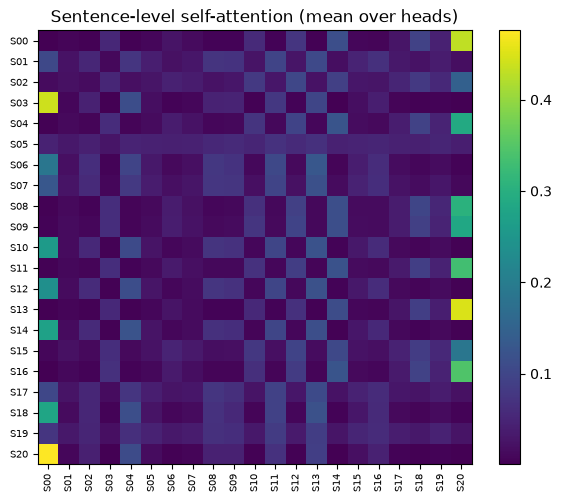

In [15]:
if RUN_NEURAL:
    import matplotlib.pyplot as plt

    t0 = time.time()
    set_seed(SEED)
    name = "Self-attention extractive"
    m = train_extractor(SelfAttentionExtractor(len(vocab)), docs, vocab, max(4, EPOCHS // 2), seed=SEED, log=print)
    idx, scores = extract(m, sents, vocab, k)
    summaries[name] = ("neural (scratch)", "extractive", " ".join(sents[i] for i in idx), idx)
    show_selection(name, idx, scores, "score")

    with torch.no_grad():
        x, lengths = pad_2d([vocab.encode(s, 40) for s in sents])
        _, pool, sent_attn = m(x, lengths, return_attention=True)
    best = int(np.argmax(scores))
    words = [vocab.itos[i] for i in x[best].tolist() if i != PAD]
    top_words = sorted(zip(words, pool[best][:len(words)].tolist()), key=lambda t: -t[1])[:6]
    print(f"Self-attention extractor - highest-scoring sentence: S{best:02d}")
    print("  words with the largest attention-pooling weights: "
          + ", ".join(f"{w} ({a:.2f})" for w, a in top_words))
    print(f"  time: {time.time() - t0:.0f}s")

    A = sent_attn.numpy()
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(A, cmap="viridis")
    ticks = list(range(len(sents)))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"S{j:02d}" for j in ticks], rotation=90, fontsize=7)
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"S{j:02d}" for j in ticks], fontsize=7)
    ax.set_title("Sentence-level self-attention (mean over heads)")
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()

**RNN encoder-decoder:** the decoder sees only the final encoder state, a single fixed-size context vector.

In [16]:
if RUN_NEURAL:
    t0 = time.time()
    set_seed(SEED)
    name = "RNN encoder-decoder (abstractive)"
    m = train_seq2seq(Seq2Seq(len(vocab), "rnn", False), pairs, vocab, EPOCHS, seed=SEED, log=print)
    text, _ = abstractive_summary(m, doc.paragraphs, vocab)
    summaries[name] = ("neural (scratch)", "abstractive", text, None)
    print(f"\n{name}:\n  {text}\n  time: {time.time() - t0:.0f}s")

      epoch  1  loss 3.0124


      epoch  4  loss 0.2124


      epoch  8  loss 0.1107
      trained in 10.5s

RNN encoder-decoder (abstractive):
  Teaching quality is good but some lectures are rushed. Infrastructure is good and classrooms are well maintained. Laboratory facilities need improvement because computers are outdated. Faculty members are approachable but email responses are slow. Overall student satisfaction is low.
  time: 11s


**LSTM encoder-decoder:** the same encoder-decoder with LSTM cells, still using only the final encoder state.

In [17]:
if RUN_NEURAL:
    t0 = time.time()
    set_seed(SEED)
    name = "LSTM encoder-decoder (abstractive)"
    m = train_seq2seq(Seq2Seq(len(vocab), "lstm", False), pairs, vocab, EPOCHS, seed=SEED, log=print)
    text, _ = abstractive_summary(m, doc.paragraphs, vocab)
    summaries[name] = ("neural (scratch)", "abstractive", text, None)
    print(f"\n{name}:\n  {text}\n  time: {time.time() - t0:.0f}s")

      epoch  1  loss 3.7457


      epoch  4  loss 0.4514


      epoch  8  loss 0.2904
      trained in 67.7s

LSTM encoder-decoder (abstractive):
  Overall student satisfaction is low. Faculty members are approachable but email responses are slow.
  time: 68s


**Seq2Seq + Bahdanau attention:** BiLSTM encoder; at every output step the decoder attends over all encoder states.
The alignment shows, for each generated word of paragraph 1, the source word with the largest attention weight.

In [18]:
if RUN_NEURAL:
    t0 = time.time()
    set_seed(SEED)
    name = "Seq2Seq + Bahdanau attention (abstractive)"
    m = train_seq2seq(Seq2Seq(len(vocab), "lstm", True), pairs, vocab, EPOCHS, seed=SEED, log=print)
    text, info = abstractive_summary(m, doc.paragraphs, vocab)
    summaries[name] = ("neural (scratch)", "abstractive", text, None)
    print(f"\n{name}:\n  {text}\n  time: {time.time() - t0:.0f}s")

    src, ids, attns = info[0]
    align = []
    for t, a in enumerate(attns):
        if a is None or ids[t].item() == EOS:
            break
        j = int(a[0].argmax())
        align.append((vocab.itos[ids[t].item()], vocab.itos[src[j].item()], float(a[0, j])))
    print("\nBahdanau attention while summarising paragraph 1 (generated word -> most-attended source word, weight):")
    print("   " + ", ".join(f"{g}->{s} ({w:.2f})" for g, s, w in align))

      epoch  1  loss 3.4765


      epoch  4  loss 0.1560


      epoch  8  loss 0.0177
      trained in 125.3s

Seq2Seq + Bahdanau attention (abstractive):
  Teaching quality is good but some lectures are rushed. Classrooms are good but wi-fi connectivity is poor. Lab staff are helpful but many computers are outdated. Faculty members are approachable but email responses are slow. Overall student satisfaction is high.
  time: 126s

Bahdanau attention while summarising paragraph 1 (generated word -> most-attended source word, weight):
   teaching->, (0.08), quality->, (0.04), is->. (0.45), good->, (0.20), but->, (0.29), some->, (0.04), lectures->, (0.05), are->. (0.12), rushed->, (0.06), .->, (0.09)


**Transformer encoder-decoder:** sinusoidal positions, multi-head self-attention in the encoder, masked
(look-ahead) self-attention and cross-attention in the decoder. Trained with a lower learning rate (5e-4).

In [19]:
if RUN_NEURAL:
    t0 = time.time()
    set_seed(SEED)
    name = "Transformer encoder-decoder (abstractive)"
    m = train_seq2seq(TransformerSummarizer(len(vocab)), pairs, vocab, EPOCHS, lr=5e-4, seed=SEED, log=print)
    text, _ = abstractive_summary(m, doc.paragraphs, vocab)
    summaries[name] = ("neural (scratch)", "abstractive", text, None)
    print(f"\n{name}:\n  {text}\n  time: {time.time() - t0:.0f}s")

      epoch  1  loss 3.6596


      epoch  4  loss 0.1474


      epoch  8  loss 0.0261
      trained in 1089.3s

Transformer encoder-decoder (abstractive):
  Teaching quality is good but some lectures are rushed. Classrooms are good but wi-fi connectivity is poor. Lab staff are helpful but many computers are outdated. Faculty members are approachable but email responses are slow. Overall student satisfaction is moderately high despite some concerns.
  time: 1090s


U:\VITc\speech lab\.venv\Lib\site-packages\torch\nn\modules\transformer.py:533: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


In [20]:
if RUN_NEURAL:
    print("Generated summaries of the from-scratch models:")
    for name, (fam, kind, text, idx) in summaries.items():
        if fam == "neural (scratch)":
            sel = f"  sentences {['S%02d' % j for j in idx]}" if idx is not None else ""
            print(f"\n[{kind}] {name}{sel}\n  {text}")

Generated summaries of the from-scratch models:

[extractive] RNN extractive (hierarchical RNN)  sentences ['S00', 'S04', 'S05', 'S11', 'S13']
  Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly. The classrooms are spacious and the new smart boards are appreciated by almost everyone. On the other hand, the Wi-Fi connectivity in the hostels and the library is poor and frequently disconnects during peak hours. Lab assistants are helpful, but the number of working systems is not sufficient for large batches. Faculty members are approachable and willing to clear doubts after class.

[extractive] LSTM extractive (hierarchical BiLSTM)  sentences ['S00', 'S04', 'S11', 'S13', 'S16']
  Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly. The classrooms are spacious and the new smart boards are appreciated by almost everyone. Lab assistants are helpful, but th

## (c2) Pre-trained transformers (Hugging Face)

BERT and SBERT sentence embeddings are clustered with K-Means, and the sentence closest to each centroid is kept
(extractive). BART, PEGASUS and T5 generate abstractive summaries from whole paragraphs packed into chunks that
fit each model's input limit. Each model call is wrapped in try/except: if a download or load fails, the message
is printed and the notebook continues. Set `RUN_PRETRAINED = False` to skip this section.

In [21]:
if RUN_PRETRAINED:
    from pretrained_summarizers import DEFAULT_MODELS, bert_extractive, seq2seq_summary

    def try_model(label, fn):
        t0 = time.time()
        try:
            out = fn()
            print(f"[OK] {label} done in {time.time() - t0:.1f}s")
            return out
        except Exception as e:  # e.g. no internet / model not in cache
            print(f"[SKIPPED] {label}: {type(e).__name__}: {str(e)[:200]}")
            return None

    print("Models used:", DEFAULT_MODELS)

Models used: {'bert': 'google-bert/bert-base-uncased', 'sbert': 'sentence-transformers/all-MiniLM-L6-v2', 'bart': 'facebook/bart-large-cnn', 'pegasus': 'google/pegasus-cnn_dailymail', 't5': 'google-t5/t5-small'}


**BERT extractive:** mean-pooled BERT embeddings, K-Means with k clusters, one sentence per cluster (Miller, 2019).
The printed centrality is the cosine similarity of each sentence to the document centroid.

In [22]:
if RUN_PRETRAINED:
    name = "BERT extractive (K-Means on BERT embeddings)"
    out = try_model("BERT extractive", lambda: bert_extractive(doc, k, DEFAULT_MODELS["bert"]))
    if out is not None:
        idx, centrality, labels = out
        summaries[name] = ("pre-trained", "extractive", " ".join(sents[i] for i in idx), idx)
        print("K-Means cluster label of each sentence:", labels.tolist())
        show_selection(name, idx, centrality, "centrality")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[OK] BERT extractive done in 9.7s
K-Means cluster label of each sentence: [0, 2, 4, 3, 1, 4, 4, 1, 1, 2, 2, 2, 4, 0, 0, 3, 0, 3, 0, 4, 3]
--- BERT extractive (K-Means on BERT embeddings) ---
  Top centralitys : S00=0.724, S12=0.701, S16=0.698, S10=0.695, S15=0.695, S02=0.690, S06=0.679
  Selected      : ['S01', 'S03', 'S04', 'S12', 'S16']
    S01: Faculty members use real-world examples, which makes difficult subjects like operating systems and machine learning easier to follow.
    S03: A few respondents also asked for more tutorial sessions before the examinations.
    S04: The classrooms are spacious and the new smart boards are appreciated by almost everyone.
    S12: Some students suggested extending the lab hours till 8 PM so that projects can be completed on time.
    S16: Overall, students feel comfortable discussing academic and career concerns with the faculty.



**SBERT extractive:** the same K-Means procedure with a sentence-transformer model (all-MiniLM-L6-v2).

In [23]:
if RUN_PRETRAINED:
    name = "SBERT extractive (K-Means on SBERT embeddings)"
    out = try_model("SBERT extractive", lambda: bert_extractive(doc, k, DEFAULT_MODELS["sbert"]))
    if out is not None:
        idx, centrality, labels = out
        summaries[name] = ("pre-trained", "extractive", " ".join(sents[i] for i in idx), idx)
        print("K-Means cluster label of each sentence:", labels.tolist())
        show_selection(name, idx, centrality, "centrality")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[OK] SBERT extractive done in 1.3s
K-Means cluster label of each sentence: [1, 2, 1, 1, 1, 4, 4, 3, 0, 2, 2, 2, 0, 1, 1, 2, 1, 1, 1, 2, 1]
--- SBERT extractive (K-Means on SBERT embeddings) ---
  Top centralitys : S02=0.342, S18=0.337, S20=0.330, S13=0.320, S00=0.308, S03=0.307, S16=0.297
  Selected      : ['S05', 'S07', 'S08', 'S09', 'S13']
    S05: On the other hand, the Wi-Fi connectivity in the hostels and the library is poor and frequently disconnects during peak hours.
    S07: The cafeteria was renovated last year and the seating space is now adequate.
    S08: The laboratory facilities need significant improvement.
    S09: Many computers in the programming labs are outdated and take a long time to boot.
    S13: Faculty members are approachable and willing to clear doubts after class.



**BART (bart-large-cnn):** denoising seq2seq model fine-tuned on CNN/DailyMail; beam search generates the summary.

In [24]:
if RUN_PRETRAINED:
    out = try_model("BART", lambda: seq2seq_summary(doc, DEFAULT_MODELS["bart"], max_input=1024))
    if out is not None:
        text, n_chunks = out
        name = f"BART ({DEFAULT_MODELS['bart'].split('/')[-1]}, abstractive)"
        summaries[name] = ("pre-trained", "abstractive", text, None)
        print(f"\n{name}  (input chunks: {n_chunks})\n  {text}")

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

[OK] BART done in 10.5s

BART (bart-large-cnn, abstractive)  (input chunks: 1)
  Most students feel that the teaching quality in the department is good and that the core concepts are explained clearly. The classrooms are spacious and the new smart boards are appreciated by almost everyone. Wi-Fi connectivity in the hostels and the library is poor and frequently disconnects during peak hours. Students appreciate the mentoring sessions conducted every month by their mentors.


**PEGASUS (pegasus-cnn_dailymail):** pre-trained with gap-sentence generation, fine-tuned on CNN/DailyMail.

In [25]:
if RUN_PRETRAINED:
    out = try_model("PEGASUS", lambda: seq2seq_summary(doc, DEFAULT_MODELS["pegasus"], max_input=1024))
    if out is not None:
        text, n_chunks = out
        name = f"PEGASUS ({DEFAULT_MODELS['pegasus'].split('/')[-1]}, abstractive)"
        summaries[name] = ("pre-trained", "abstractive", text, None)
        print(f"\n{name}  (input chunks: {n_chunks})\n  {text}")

Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

[OK] PEGASUS done in 14.6s

PEGASUS (pegasus-cnn_dailymail, abstractive)  (input chunks: 1)
  Most students feel that the teaching quality in the department is good . The Wi-Fi connectivity in the hostels and the library is poor and frequently disconnects during peak hours. Many computers in the programming labs are outdated and take a long time to boot. Students would recommend the programme to their juniors .


**T5 (t5-small):** text-to-text model; the input is prefixed with `summarize: ` and limited to 512 tokens.

In [26]:
if RUN_PRETRAINED:
    out = try_model("T5", lambda: seq2seq_summary(doc, DEFAULT_MODELS["t5"], prefix="summarize: ",
                                                  max_input=512, max_new_tokens=90, min_length=50))
    if out is not None:
        text, n_chunks = out
        name = f"T5 ({DEFAULT_MODELS['t5'].split('/')[-1]}, abstractive)"
        summaries[name] = ("pre-trained", "abstractive", text, None)
        print(f"\n{name}  (input chunks: {n_chunks})\n  {text}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

[OK] T5 done in 3.1s

T5 (t5-small, abstractive)  (input chunks: 1)
  most students feel that the teaching quality in the department is good and that the core concepts are explained clearly. some students mentioned that some lectures are rushed towards the end of the semester. a few respondents also asked for more tutorial sessions before the examinations.


## (d) ROUGE evaluation (implemented from scratch)

`rouge.py` computes ROUGE-1 and ROUGE-2 (clipped n-gram overlap) and ROUGE-L (longest common subsequence), each as
precision, recall and F1. Every summary is compared with the human reference in `data/reference_summary.txt`.

In [27]:
from rouge import rouge_all

demo_c, demo_r = "the cat sat on the mat", "the cat is on the mat"
print(f"Hand-checkable example: candidate = {demo_c!r}, reference = {demo_r!r}")
for metric, (p, r_, f1) in rouge_all(demo_c, demo_r).items():
    print(f"  {metric}: P = {p:.3f}  R = {r_:.3f}  F1 = {f1:.3f}")

Hand-checkable example: candidate = 'the cat sat on the mat', reference = 'the cat is on the mat'
  ROUGE-1: P = 0.833  R = 0.833  F1 = 0.833
  ROUGE-2: P = 0.600  R = 0.600  F1 = 0.600
  ROUGE-L: P = 0.833  R = 0.833  F1 = 0.833


In [28]:
rows = []                       # (name, family, kind, n_words, {metric: (P, R, F1)})
for name, (fam, kind, text, _) in summaries.items():
    rows.append((name, fam, kind, len(text.split()), rouge_all(text, reference)))

hdr = ["Method", "Type", "Words", "R-1 P", "R-1 R", "R-1 F1", "R-2 P", "R-2 R", "R-2 F1",
       "R-L P", "R-L R", "R-L F1"]
md_lines = ["| " + " | ".join(hdr) + " |", "|" + "---|" * len(hdr)]
for name, fam, kind, n, r in rows:
    vals = [r[m][j] for m in ("ROUGE-1", "ROUGE-2", "ROUGE-L") for j in range(3)]
    md_lines.append(f"| {name} | {kind} | {n} | " + " | ".join(f"{v:.3f}" for v in vals) + " |")
display(Markdown("\n".join(md_lines)))

| Method | Type | Words | R-1 P | R-1 R | R-1 F1 | R-2 P | R-2 R | R-2 F1 | R-L P | R-L R | R-L F1 |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Lead baseline (first sentence of each paragraph) | extractive | 68 | 0.529 | 0.480 | 0.503 | 0.328 | 0.297 | 0.312 | 0.485 | 0.440 | 0.462 |
| Frequency-based | extractive | 83 | 0.274 | 0.307 | 0.289 | 0.096 | 0.108 | 0.102 | 0.202 | 0.227 | 0.214 |
| TF-IDF | extractive | 66 | 0.418 | 0.373 | 0.394 | 0.212 | 0.189 | 0.200 | 0.343 | 0.307 | 0.324 |
| TextRank | extractive | 76 | 0.276 | 0.280 | 0.278 | 0.093 | 0.095 | 0.094 | 0.211 | 0.213 | 0.212 |
| LexRank | extractive | 82 | 0.329 | 0.360 | 0.344 | 0.160 | 0.176 | 0.168 | 0.268 | 0.293 | 0.280 |
| Feature-based scoring | extractive | 75 | 0.461 | 0.467 | 0.464 | 0.253 | 0.257 | 0.255 | 0.368 | 0.373 | 0.371 |
| RNN extractive (hierarchical RNN) | extractive | 82 | 0.482 | 0.533 | 0.506 | 0.268 | 0.297 | 0.282 | 0.410 | 0.453 | 0.430 |
| LSTM extractive (hierarchical BiLSTM) | extractive | 73 | 0.479 | 0.467 | 0.473 | 0.208 | 0.203 | 0.205 | 0.370 | 0.360 | 0.365 |
| Self-attention extractive | extractive | 73 | 0.479 | 0.467 | 0.473 | 0.208 | 0.203 | 0.205 | 0.370 | 0.360 | 0.365 |
| RNN encoder-decoder (abstractive) | abstractive | 39 | 0.872 | 0.453 | 0.596 | 0.605 | 0.311 | 0.411 | 0.795 | 0.413 | 0.544 |
| LSTM encoder-decoder (abstractive) | abstractive | 14 | 0.929 | 0.173 | 0.292 | 0.615 | 0.108 | 0.184 | 0.643 | 0.120 | 0.202 |
| Seq2Seq + Bahdanau attention (abstractive) | abstractive | 40 | 0.878 | 0.480 | 0.621 | 0.600 | 0.324 | 0.421 | 0.829 | 0.453 | 0.586 |
| Transformer encoder-decoder (abstractive) | abstractive | 44 | 0.844 | 0.507 | 0.633 | 0.591 | 0.351 | 0.441 | 0.800 | 0.480 | 0.600 |
| BERT extractive (K-Means on BERT embeddings) | extractive | 74 | 0.240 | 0.240 | 0.240 | 0.054 | 0.054 | 0.054 | 0.147 | 0.147 | 0.147 |
| SBERT extractive (K-Means on SBERT embeddings) | extractive | 66 | 0.433 | 0.387 | 0.408 | 0.258 | 0.230 | 0.243 | 0.358 | 0.320 | 0.338 |
| BART (bart-large-cnn, abstractive) | abstractive | 61 | 0.452 | 0.373 | 0.409 | 0.279 | 0.230 | 0.252 | 0.435 | 0.360 | 0.394 |
| PEGASUS (pegasus-cnn_dailymail, abstractive) | abstractive | 54 | 0.415 | 0.293 | 0.344 | 0.250 | 0.176 | 0.206 | 0.377 | 0.267 | 0.312 |
| T5 (t5-small, abstractive) | abstractive | 46 | 0.348 | 0.213 | 0.264 | 0.222 | 0.135 | 0.168 | 0.326 | 0.200 | 0.248 |

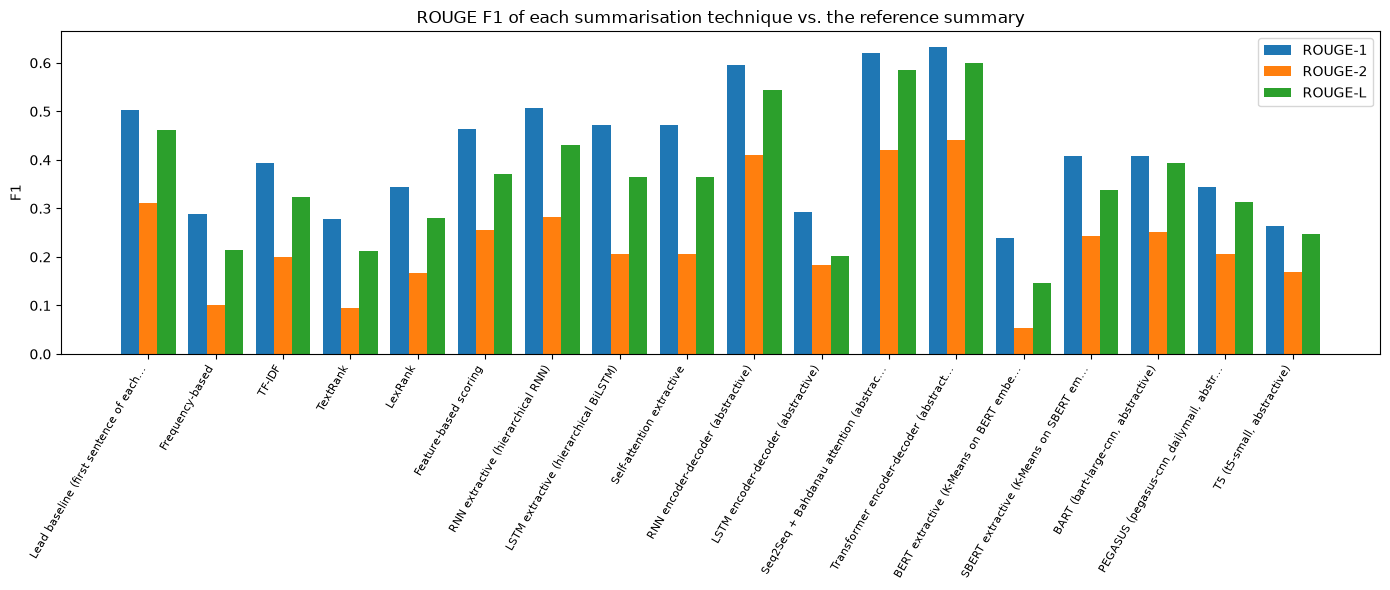

Chart saved to U:\VITc\speech lab\notebooks\lab5_outputs\rouge_chart.png


In [29]:
import matplotlib.pyplot as plt

def short(s, n=95):
    return s if len(s) <= n else s[:n - 3] + "..."

x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(14, 6))
for off, metric in zip((-0.27, 0, 0.27), ("ROUGE-1", "ROUGE-2", "ROUGE-L")):
    ax.bar(x + off, [r[metric][2] for _, _, _, _, r in rows], 0.27, label=metric)
ax.set_xticks(x)
ax.set_xticklabels([short(name, 40) for name, _, _, _, _ in rows], rotation=60, ha="right", fontsize=8)
ax.set_ylabel("F1")
ax.set_title("ROUGE F1 of each summarisation technique vs. the reference summary")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "rouge_chart.png", dpi=130)
plt.show()
print("Chart saved to", OUT / "rouge_chart.png")

## Final comparison

Methods ranked by ROUGE-L F1 against the reference summary. The CAUTION note from `main.py` follows the table.

In [30]:
ranked = sorted(rows, key=lambda t: -t[4]["ROUGE-L"][2])
L = ["| Rank | Method | Type | ROUGE-1 F1 | ROUGE-2 F1 | ROUGE-L F1 |", "|---|---|---|---|---|---|"]
for i, (name, fam, kind, n, r) in enumerate(ranked, 1):
    L.append(f"| {i} | {name} | {kind} | {r['ROUGE-1'][2]:.3f} | {r['ROUGE-2'][2]:.3f} | {r['ROUGE-L'][2]:.3f} |")
best = ranked[0]
best_ext = max((t for t in rows if t[2] == "extractive"), key=lambda t: t[4]["ROUGE-L"][2])
abst = [t for t in rows if t[2] == "abstractive"]
L += ["",
      f"**Best overall (ROUGE-L F1):** {best[0]} = {best[4]['ROUGE-L'][2]:.3f}  ",
      f"**Best extractive:** {best_ext[0]} = {best_ext[4]['ROUGE-L'][2]:.3f}  "]
if abst:
    best_abs = max(abst, key=lambda t: t[4]["ROUGE-L"][2])
    L.append(f"**Best abstractive:** {best_abs[0]} = {best_abs[4]['ROUGE-L'][2]:.3f}  ")
display(Markdown("\n".join(L)))

| Rank | Method | Type | ROUGE-1 F1 | ROUGE-2 F1 | ROUGE-L F1 |
|---|---|---|---|---|---|
| 1 | Transformer encoder-decoder (abstractive) | abstractive | 0.633 | 0.441 | 0.600 |
| 2 | Seq2Seq + Bahdanau attention (abstractive) | abstractive | 0.621 | 0.421 | 0.586 |
| 3 | RNN encoder-decoder (abstractive) | abstractive | 0.596 | 0.411 | 0.544 |
| 4 | Lead baseline (first sentence of each paragraph) | extractive | 0.503 | 0.312 | 0.462 |
| 5 | RNN extractive (hierarchical RNN) | extractive | 0.506 | 0.282 | 0.430 |
| 6 | BART (bart-large-cnn, abstractive) | abstractive | 0.409 | 0.252 | 0.394 |
| 7 | Feature-based scoring | extractive | 0.464 | 0.255 | 0.371 |
| 8 | LSTM extractive (hierarchical BiLSTM) | extractive | 0.473 | 0.205 | 0.365 |
| 9 | Self-attention extractive | extractive | 0.473 | 0.205 | 0.365 |
| 10 | SBERT extractive (K-Means on SBERT embeddings) | extractive | 0.408 | 0.243 | 0.338 |
| 11 | TF-IDF | extractive | 0.394 | 0.200 | 0.324 |
| 12 | PEGASUS (pegasus-cnn_dailymail, abstractive) | abstractive | 0.344 | 0.206 | 0.312 |
| 13 | LexRank | extractive | 0.344 | 0.168 | 0.280 |
| 14 | T5 (t5-small, abstractive) | abstractive | 0.264 | 0.168 | 0.248 |
| 15 | Frequency-based | extractive | 0.289 | 0.102 | 0.214 |
| 16 | TextRank | extractive | 0.278 | 0.094 | 0.212 |
| 17 | LSTM encoder-decoder (abstractive) | abstractive | 0.292 | 0.184 | 0.202 |
| 18 | BERT extractive (K-Means on BERT embeddings) | extractive | 0.240 | 0.054 | 0.147 |

**Best overall (ROUGE-L F1):** Transformer encoder-decoder (abstractive) = 0.600  
**Best extractive:** Lead baseline (first sentence of each paragraph) = 0.462  
**Best abstractive:** Transformer encoder-decoder (abstractive) = 0.600  

In [31]:
# Save the same files as main.py, but into notebooks/lab5_outputs (never into lab 5/solution/outputs)
with open(OUT / "rouge_scores.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["method", "family", "type", "words", "rouge1_p", "rouge1_r", "rouge1_f",
                "rouge2_p", "rouge2_r", "rouge2_f", "rougeL_p", "rougeL_r", "rougeL_f"])
    for name, fam, kind, n, r in rows:
        w.writerow([name, fam, kind, n] + [round(v, 4) for m in ("ROUGE-1", "ROUGE-2", "ROUGE-L")
                                           for v in r[m]])
r_by_name = {name: r for name, _, _, _, r in rows}
with open(OUT / "summaries.md", "w", encoding="utf-8") as f:
    f.write("# Generated summaries\n\n## Reference\n\n" + reference + "\n\n")
    for name, (fam, kind, text, _) in summaries.items():
        r = r_by_name[name]
        f.write(f"## {name}\n\n*{fam}, {kind}* - ROUGE-1 {r['ROUGE-1'][2]:.3f}, "
                f"ROUGE-2 {r['ROUGE-2'][2]:.3f}, ROUGE-L {r['ROUGE-L'][2]:.3f}\n\n{text}\n\n")
print("Saved:", OUT / "rouge_scores.csv", "|", OUT / "summaries.md", "|", OUT / "rouge_chart.png")

Saved: U:\VITc\speech lab\notebooks\lab5_outputs\rouge_scores.csv | U:\VITc\speech lab\notebooks\lab5_outputs\summaries.md | U:\VITc\speech lab\notebooks\lab5_outputs\rouge_chart.png


In [32]:
CAUTION = (
    "> **CAUTION when reading the table:** the synthetic training targets of the from-scratch abstractive "
    "models use the same short phrasing style as the reference summary (\"X is good but Y is poor\"). "
    "Their high ROUGE is therefore partly a vocabulary/style match, not proof that they are better "
    "summarisers than BART/PEGASUS. Check faithfulness manually: an abstractive model can be fluent "
    "and still state the wrong polarity (e.g. \"laboratory facilities are good\") - ROUGE does not "
    "detect such hallucinations."
)
display(Markdown(CAUTION))

> **CAUTION when reading the table:** the synthetic training targets of the from-scratch abstractive models use the same short phrasing style as the reference summary ("X is good but Y is poor"). Their high ROUGE is therefore partly a vocabulary/style match, not proof that they are better summarisers than BART/PEGASUS. Check faithfulness manually: an abstractive model can be fluent and still state the wrong polarity (e.g. "laboratory facilities are good") - ROUGE does not detect such hallucinations.

## Notes / what to look for

- **(a)** Check the "Removed unnecessary text" log: the document title, metadata lines, separator line, the URL
  sentence, the boiler-plate sentence and the bracketed editorial note are removed; repeated punctuation is
  normalised. Headings are kept as paragraph labels.
- **Extractive vs. abstractive:** extractive methods copy whole sentences, so they cannot paraphrase; abstractive
  models write new sentences. In the (d) table, compare precision (how much of each summary matches the
  reference) with recall (how much of the reference is covered) to see whether a summary is too long or too short.
- **Graph vs. statistical:** TextRank and LexRank reward sentences that share words with many others; Frequency
  and TF-IDF sums reward long sentences; the feature-based scorer adds position and heading keywords.
- **From-scratch models** learn only from the synthetic corpus. Their ROUGE is partly a style match (see the
  CAUTION note above), so check the generated text itself, including its polarity.
- **Pre-trained BART and PEGASUS** were fine-tuned on news articles (CNN/DailyMail): their output is fluent but
  news-styled and partly copied from the input.
- **Extractor scores saturate:** after training on the small synthetic corpus, many sentence scores are close to
  1.0 (see the "Top scores" lines in (c1)), so the top-k choice among them is partly arbitrary. Identical selections
  from different extractors (e.g. the LSTM and self-attention models) can happen for this reason.
- **One document, one reference:** differences of a few ROUGE points are not statistically meaningful. A real
  evaluation would use many reports and several references.
- **Differences from `main.py`:** a random seed is set before each from-scratch model is built (so these results
  are reproducible inside the notebook); the pre-trained models are called one by one, each in try/except; the
  output files go to `notebooks/lab5_outputs/`.